# Get Predictions

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def makeGaussian(size, fwhm = 60, center=None):
    """ Make a square gaussian kernel.

    size is the length of a side of the square
    fwhm is full-width-half-maximum, which
    can be thought of as an effective radius.
    """

    x = np.arange(0, size, 1, float)
    print(x)
    y = x[:,np.newaxis]


    if center is None:
        x0 = y0 = size // 2
    else:
        x0 = center[0]
        y0 = center[1]

    return np.exp(-4*np.log(2) * ((x-x0)**2 + (y-y0)**2) / fwhm **2)

m = makeGaussian(128)
print(m.shape)
plt.imshow(x)

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127.]
(128, 128)


NameError: name 'x' is not defined

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm
import pandas as pd
from pathlib import Path
import numpy as np
import tensorflow as tf
from glob import glob
import sys

sys.path.append("../Step 3 - Training/code/phd")

from Augmentations.common_code.training_loop import get_dataset_with_objids, get_objids_only
from Augmentations.common_code.utils import reset_tpu

@tf.function()
def get_predictions(model, dataset):

    galaxy_ids = np.empty([0, 1], dtype=str)
    true_labels = np.empty([0, 1], dtype=float)
    predictions = np.empty([0, 1], dtype=float)

    for images, labels, objids in tqdm(dataset):
        results = model(images, training=False)
        galaxy_ids = tf.concat([tf.reshape(objids, [-1, 1]), galaxy_ids], axis=0)
        true_labels = tf.concat([tf.reshape(labels, [-1, 1]), true_labels], axis=0)
        predictions = tf.concat([tf.reshape(tf.argmax(results, axis= 1), [-1, 1]), predictions], axis=0)
    
    return (galaxy_ids, true_labels, predictions)


NUMBER_OF_FOLDS = 5



gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)

for NUMBER_OF_CLASSES in [2]:
    model_paths = glob(f"./MCCV_models/{NUMBER_OF_CLASSES}_classes/*/*")
    for model_path in model_paths:
        model_path = model_path.replace("\\", "/")
        parts = model_path.split("/")
        experiment_name = parts[3]
        model_name = parts[4]
        split_name = experiment_name[-5:].replace("_", "")
        print(split_name)
        accuracies = []
        precisions = []
        recalls = []
        f1s = []

        for fold in range(1, NUMBER_OF_FOLDS + 1):
            strategy = reset_tpu({"TPU" : False})
            with strategy.scope():
                if not os.path.exists(f"{model_path}/best_loss/fold_{fold}"):
                    print(f"FOLD {fold} DOES NOT EXIST!")
                    continue

                print(f"./MCCV_predictions/{'/'.join(parts[2:])}/fold_{fold}.csv")
                if not os.path.exists(f"./MCCV_predictions/{'/'.join(parts[2:])}/fold_{fold}.csv"):

                    model = tf.keras.models.load_model(f"{model_path}/best_loss/fold_{fold}")

                    galaxy_ids = np.empty([0, 1], dtype=str)
                    true_labels = np.empty([0, 1], dtype=float)
                    predictions = np.empty([0, 1], dtype=float)

                    dataset = get_dataset_with_objids(f"../Step 2 (Bins) - Image dataset/TFDataset/MCCV/{NUMBER_OF_CLASSES}_Classes/{split_name}/fold_{fold}/test", 512)

                    for images, labels, objids in tqdm(dataset):
                        results = model(images, training=False)
                        galaxy_ids = tf.concat([tf.reshape(objids, [-1, 1]), galaxy_ids], axis=0)
                        true_labels = tf.concat([tf.reshape(labels, [-1, 1]), true_labels], axis=0)
                        predictions = tf.concat([tf.reshape(tf.argmax(results, axis= 1), [-1, 1]), predictions], axis=0)

                    prediction_dataframe = pd.DataFrame({
                        "Id": galaxy_ids.numpy().astype(str).reshape((-1)),
                        "True": true_labels.numpy().reshape((-1)),
                        "Prediction": predictions.numpy().reshape((-1))
                    })

                    Path(f"./MCCV_predictions/{'/'.join(parts[2:])}").mkdir(parents=True, exist_ok=True)
                    prediction_dataframe.to_csv(f"./MCCV_predictions/{'/'.join(parts[2:])}/fold_{fold}.csv")

                    del model
                    del dataset
                    del galaxy_ids
                else:
                    print(f"PATH ALREADY EXISTS: ./MCCV_predictions/{'/'.join(parts[2:])}")
            
            tf.keras.backend.clear_session()

# Predictions to CSV

In [6]:
from glob import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score

NUMBER_OF_FOLDS = 1
CLASSES = [3]

def get_prediction_dataframe(paths, testing):
    dataframe_baseline = pd.DataFrame([], columns = ['model_name', 'split_name', 'fold', 'accuracy', 'precision', 'recall', 'f1'])
    for path in paths:
        parts = path.replace("\\", "/").split("/")
        model_name = parts[6]
        experiment_name = parts[5]
        split_name = experiment_name.replace("_no_noise", "").split("_")[-1]
        for fold in range(1, NUMBER_OF_FOLDS + 1):
            if(os.path.exists(f"{path}/{testing}.csv".replace("\\", "/"))):
                
                dataset = pd.read_csv(f"{path}/{testing}.csv".replace("\\", "/"))
                true_labels = dataset["True"].to_numpy().T
                predictions = dataset["Prediction"].to_numpy().T

                new_df = pd.DataFrame([[
                    model_name,
                    split_name,
                    fold,
                    accuracy_score(true_labels, predictions),
                    precision_score(true_labels, predictions, average = 'binary' if NUMBER_OF_CLASSES == 2 else 'macro'),
                    recall_score(true_labels, predictions, average = 'binary' if NUMBER_OF_CLASSES == 2 else 'macro'),
                    f1_score(true_labels, predictions, average = 'binary' if NUMBER_OF_CLASSES == 2 else 'macro')
                ]], columns = ['model_name', 'split_name', 'fold', 'accuracy', 'precision', 'recall', 'f1'])

                dataframe_baseline = pd.concat([dataframe_baseline, new_df])
        
    return dataframe_baseline

os.makedirs(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/", exist_ok=True)

for class_index, NUMBER_OF_CLASSES in enumerate(CLASSES):
    augmented_model_paths = sorted(glob(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/predictions/TrainTestValidation_augmentations_{NUMBER_OF_CLASSES}_classes_*_no_noise/*"))
    non_augmented_model_paths = sorted(glob(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/predictions/TrainTestValidation_no_augmentations_{NUMBER_OF_CLASSES}_classes_*_no_noise/*"))

    print(f"{NUMBER_OF_CLASSES} classes, no augmentations, test")
    non_augmented_dataframe = get_prediction_dataframe(non_augmented_model_paths, "test")
    non_augmented_dataframe.to_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/{NUMBER_OF_CLASSES}_classes_results_no_augmentations_test_no_noise.csv", index=False)

    print(f"{NUMBER_OF_CLASSES} classes, no augmentations, validation")
    non_augmented_dataframe = get_prediction_dataframe(non_augmented_model_paths, "validation")
    non_augmented_dataframe.to_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/{NUMBER_OF_CLASSES}_classes_results_no_augmentations_validation_no_noise.csv", index=False)

    print(f"{NUMBER_OF_CLASSES} classes, with augmentations, test")
    augmented_dataframe = get_prediction_dataframe(augmented_model_paths, "test")
    augmented_dataframe.to_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/{NUMBER_OF_CLASSES}_classes_results_with_augmentations_test_no_noise.csv", index=False)

    print(f"{NUMBER_OF_CLASSES} classes, with augmentations, validation")
    augmented_dataframe = get_prediction_dataframe(augmented_model_paths, "validation")
    augmented_dataframe.to_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/{NUMBER_OF_CLASSES}_classes_results_with_augmentations_validation_no_noise.csv", index=False)

3 classes, no augmentations, test
3 classes, no augmentations, validation


/tmp/ipykernel_753/822666270.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataframe_baseline = pd.concat([dataframe_baseline, new_df])
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/loca

3 classes, with augmentations, test
3 classes, with augmentations, validation


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning

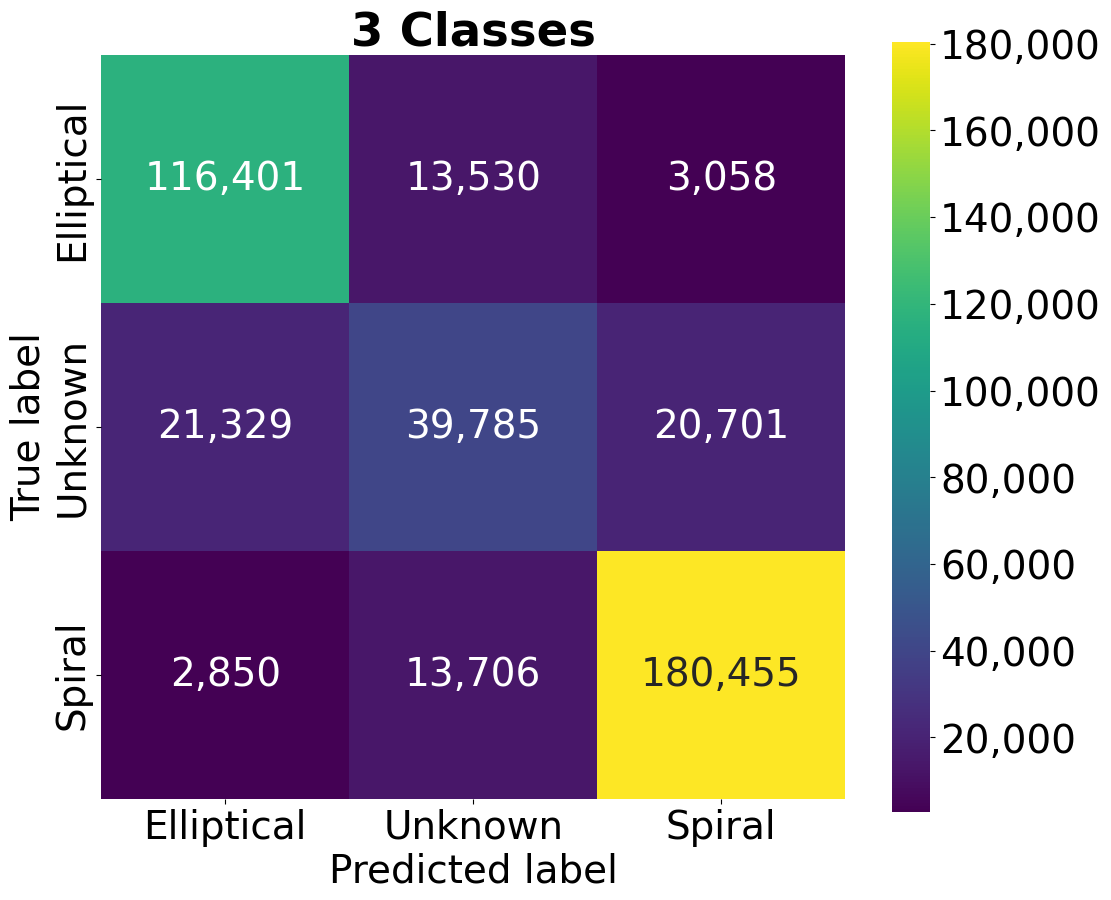

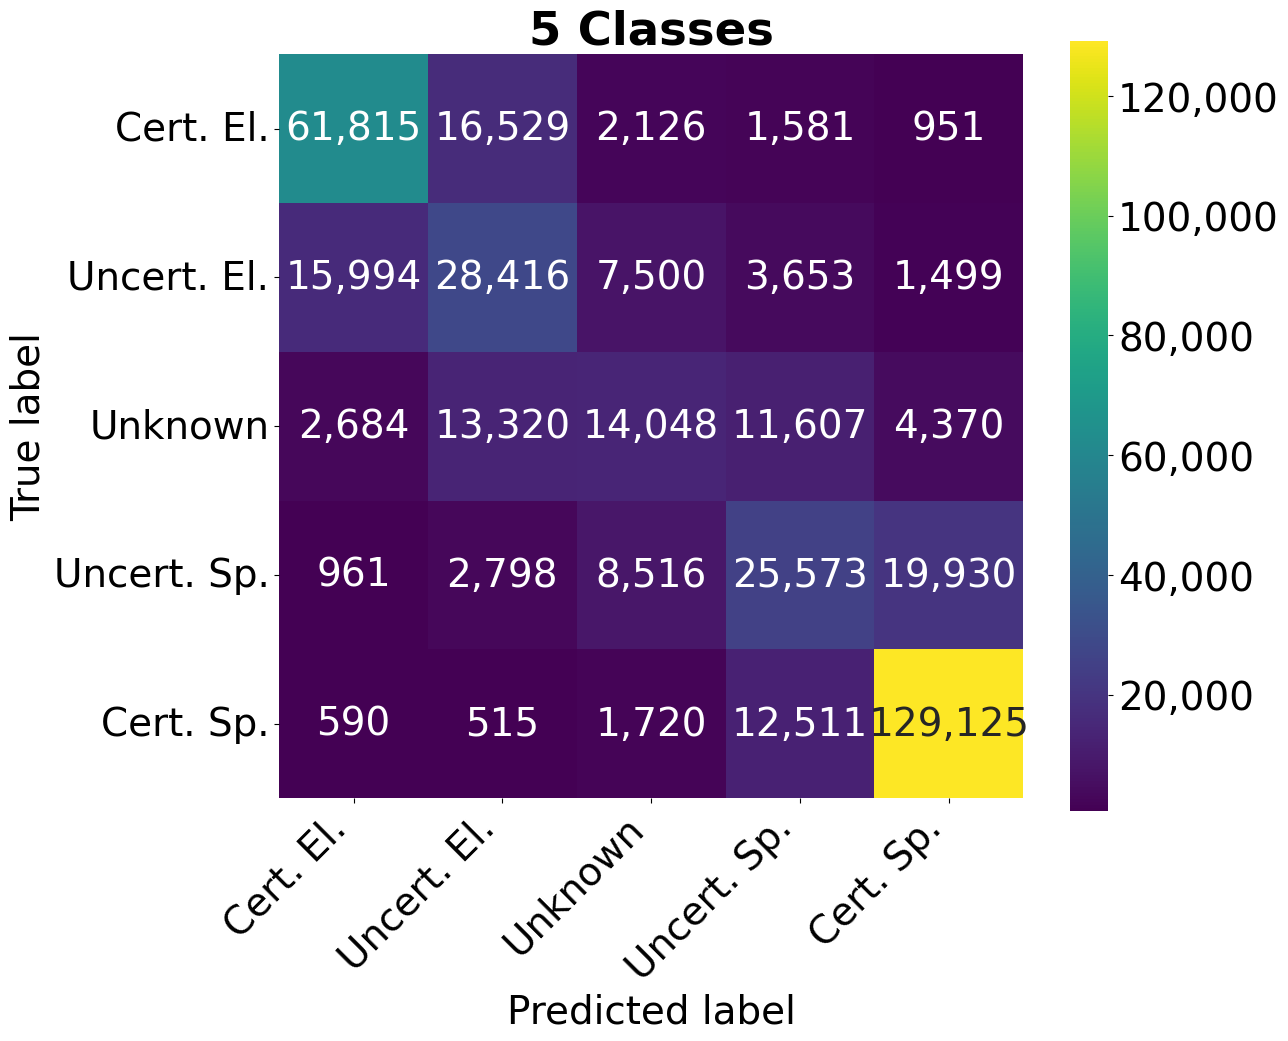

In [145]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sn

plt.rcParams.update({'font.size': 28})


def fmt(x, pos):
    return '{:,d}'.format(int(x))

data = pd.read_csv("D:/phd_new/Step 4 - Result evaluation/MCCV_predictions/3_classes/paper1_augmentations_3_classes_46-54/cavanagh/fold_3.csv")

# disp = ConfusionMatrixDisplay.from_predictions(data["True"], data["Prediction"], display_labels=["Elliptical", "Unknown", "Spiral"], xticks_rotation='vertical', text_kw={"fontsize": 28}, values_format=',')

plt.figure(figsize=(12, 10))
cm =(confusion_matrix(data["True"], data["Prediction"]))

df_cm = pd.DataFrame(cm, index = pd.Index(["Elliptical", "Unknown", "Spiral"], name='True label'),
                  columns = pd.Index(["Elliptical", "Unknown", "Spiral"], name='Predicted label'))

                  
plt.title("3 Classes", fontweight="bold")
plt.xlabel("asfg")

sn.heatmap(df_cm, annot=True, fmt = ",", cbar_kws={ "format": matplotlib.ticker.FuncFormatter(fmt) }, cmap ='viridis', square = True)


plt.savefig("3_classes_matrix.pdf", bbox_inches='tight')

# fig = disp.ax_.get_figure() 
# fig.set_figwidth(10)
# fig.set_figheight(10)
# plt.title("3 Classes", fontweight="bold")
# fig.tight_layout()
# plt.savefig("3_classes_matrix.pdf", bbox_inches='tight')

data = pd.read_csv("D:/phd_new/Step 4 - Result evaluation/MCCV_predictions/5_classes/paper1_augmentations_5_classes_46-54/cavanagh/fold_10.csv")

# disp = ConfusionMatrixDisplay.from_predictions(data["True"], data["Prediction"], display_labels=["Cert. El.", "Uncert. El.", "Unknown", "Uncert. Sp.", "Cert. Sp."], xticks_rotation=75, colorbar=False,  text_kw={"fontsize": 22}, values_format=',')
# fig = disp.ax_.get_figure() 
# fig.set_figwidth(10)
# fig.set_figheight(10)
# fig.colorbar(disp.confusion_matrix)

# fig.tight_layout()

# plt.savefig("5_classes_matrix.pdf", bbox_inches='tight')



plt.figure(figsize=(12, 10))
cm=(confusion_matrix(data["True"], data["Prediction"]))

df_cm = pd.DataFrame(cm, index = pd.Index(["Cert. El.", "Uncert. El.", "Unknown", "Uncert. Sp.", "Cert. Sp."], name='True label'),
                  columns = pd.Index(["Cert. El.", "Uncert. El.", "Unknown", "Uncert. Sp.", "Cert. Sp."], name='Predicted label'))

                  
plt.title("5 Classes", fontweight="bold")


sn.heatmap(df_cm, annot=True, fmt = ",", cbar_kws={ "format": matplotlib.ticker.FuncFormatter(fmt) }, cmap ='viridis', square = True)

plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0) 

plt.savefig("5_classes_matrix.pdf", bbox_inches = 'tight')

# Box plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 24})



models = [
    { "name": "cavanagh", "display_name": "Cavanagh"},
    { "name": "resnet50", "display_name": "ResNet50"},
    { "name": "effnet", "display_name": "EfficientNetV2S"}
]

classes = [
    {"count": 2, "min": 80, "max": 95},
    # {"count": 2, "min": 45, "max": 90},
    # {"count": 3, "min": 50, "max": 90},
    # {"count": 3, "min": 35, "max": 80},
    # # {"count": 5, "min": 30, "max": 70},
    # {"count": 5, "min": 20, "max": 70},
]
splits = [
    # { "name": "0-100", "display_name": "0.4"},
    # { "name": "01-99", "display_name": "1.0"},
    # { "name": "02-98", "display_name": "2.2"},
    # { "name": "05-95", "display_name": "4.6"},
    { "name": "10-90", "display_name": "10.0"},
    { "name": "22-78", "display_name": "21.5"},
    { "name": "46-54", "display_name": "46.4"},
]

def box_plot(ax, data, edge_color, fill_color, alpha, labels):
    bp = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=False)
    
    for element in ['boxes', 'whiskers', 'fliers', 'means', 'medians', 'caps']:
        plt.setp(bp[element], color=edge_color, alpha = alpha)

    for patch in bp['boxes']:
        patch.set(facecolor=fill_color)       

    for patch in bp['fliers']:
        patch.set(markeredgecolor="black", markerfacecolor="black")  
        
    return bp


# clear subplots
fig = plt.figure(constrained_layout=True, figsize=(18, 6 * len(classes)), dpi=300)

# create 3x1 subfigs
subfigs = fig.subfigures(nrows=len(classes), ncols=1)

for class_index, class_item in enumerate(classes):

    number_of_classes = class_item["count"]

    if (len(classes) > 1):
        subfigs[class_index].suptitle(f'{number_of_classes} classes', fontsize=24)
        ax = subfigs[class_index].subplots(nrows=1, ncols=3, sharey=True)
    else:
        ax = subfigs.subplots(nrows=1, ncols=3, sharey=True)

    for model_index, model in enumerate(models):
        model_name = model["name"]
        non_augmented_data = pd.read_csv(f"{number_of_classes}_classes_results_no_augmentations.csv")
        augmented_data = pd.read_csv(f"{number_of_classes}_classes_results_with_augmentations.csv")
        non_augmented_accuracies = []
        augmented_accuracies = []

        for split in splits:
            non_augmented_accuracies.append(non_augmented_data[(non_augmented_data["model_name"] == model_name) & (non_augmented_data["split_name"] == split["name"])]["accuracy"] * 100)
            augmented_accuracies.append(augmented_data[(augmented_data["model_name"] == model_name) & (augmented_data["split_name"] == split["name"])]["accuracy"] * 100)

        bp1 = box_plot(ax[model_index], non_augmented_accuracies, "blue", "lightblue", 1, labels=[f"{split['display_name']}" for split in splits])
        bp2 = box_plot(ax[model_index], augmented_accuracies, "red", "orange", 0.6, labels=[f"{split['display_name']}" for split in splits])
        
        # ax[model_index].set_yticks(np.arange(class_item["min"], class_item["max"] + 1, (class_item["max"] - class_item["min"]) / 5))
        ax[model_index].set_title(model["display_name"])

        ax[model_index].set_xlabel("Training dataset split, %", fontsize=22)
        if model_index == 0:
            ax[model_index].set_ylabel("Accuracy, %")
        if model_index == (len(models) - 1):
            ax[model_index].legend([bp1["boxes"][0], bp2["boxes"][0]], ['Baseline',   'Augmented'], loc='lower right')
        ax[model_index].grid()

plt.savefig("large_splits_2_class.pdf")


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 30})

plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = False

fig = plt.figure(figsize=(24, 16), dpi=1000)
ax = fig.subplots(nrows=2, ncols=2)
values = [338786, 461662]
ax[0][0].bar(["Elliptical", "Spiral"], values, alpha=0.4)
ax[0][0].set_title("2 classes", fontweight="bold", y=1.1)
ax[0][0].get_yaxis().set_visible(False)
for index, value in enumerate(values):
    ax[0][0].text(index, value + 1000, 
             f'{value:,} ({value / sum(values) * 100:.0f}%)', ha = 'center')

ax[0][0].set_ylim([0, 461662 + 461662 * 0.15])


values = [246188, 151702, 364730]
ax[0][1].bar(["Elliptical", "Unknown", "Spiral"], values, alpha=0.4)
ax[0][1].set_title("3 classes", fontweight="bold", y=1.1)
ax[0][1].get_yaxis().set_visible(False)

for index, value in enumerate(values):
    ax[0][1].text(index, value + 1000, 
             f'{value:,} ({value / sum(values) * 100:.0f}%)', ha = 'center')

ax[0][1].set_ylim([0, 364730 + 364730 * 0.15])


values = [154072, 105415, 84801, 107088, 267757]
ax[1][0].bar(["Certain Elliptical", "Uncertain Elliptical", "Unkown", "Uncertain Spiral", "Certain Spiral"], values, alpha=0.4)
ax[1][0].set_title("5 classes", fontweight="bold", y=1.1)
ax[1][0].set_xticklabels(["Certain Elliptical", "Uncertain Elliptical", "Unkown", "Uncertain Spiral", "Certain Spiral"], rotation=340, ha='left', fontsize = 26)
ax[1][0].get_yaxis().set_visible(False)

for index, value in enumerate(values):
    ax[1][0].text(index, value + 1000, 
             f'{value:,} ({value / sum(values) * 100:.0f}%)', ha = 'center',fontsize = 26)

ax[1][0].set_ylim([0, 267757 + 267757 * 0.1])

fig.delaxes(ax[1][1])

plt.tight_layout()
plt.savefig("class_distribution.pdf")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

loss = pd.read_csv("wandb_export_2024-04-09T23_51_31.374+03_00.csv")["DATASET_PATH: data/TFDataset/MCCV/2_Classes/00-100 - loss"]
acc = pd.read_csv("wandb_export_2024-04-09T23_55_06.316+03_00.csv")["DATASET_PATH: data/TFDataset/MCCV/2_Classes/00-100 - acc"]


fig = plt.figure(figsize=(8, 6), dpi=300)
# fig.set_constrained_layout_pads( wspace=0.1, hspace=0.5)
# ax = fig.subplots(nrows=1, ncols=2)

plt.plot(loss, label = "Loss", linewidth=4)
plt.plot(acc, label = "Accuracy", linewidth=4)
plt.grid()
plt.legend(fontsize=24)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1])
plt.xlabel("Steps", fontsize=24)
plt.ylabel("Metric value", fontsize=24)
plt.yticks(fontsize=24)
plt.xticks(fontsize=24)
plt.title("Overfitting model", fontweight="bold", y=1.05, fontsize=28)

plt.tight_layout()
plt.savefig("overfitting_model_1.pdf")


loss = pd.read_csv("wandb_export_2024-04-10T00_13_25.506+03_00.csv")["DATASET_PATH: data/TFDataset/MCCV/2_Classes/10-90 - loss"]
acc = pd.read_csv("wandb_export_2024-04-10T00_14_09.084+03_00.csv")["DATASET_PATH: data/TFDataset/MCCV/2_Classes/10-90 - acc"]

fig = plt.figure(figsize=(8, 6), dpi=300)
plt.plot(loss, label = "Loss", linewidth=4)
plt.plot(acc, label = "Accuracy", linewidth=4)
plt.grid()
plt.legend(fontsize=24)
plt.xlabel("Steps", fontsize=24)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1])
plt.yticks(fontsize=24)
plt.xticks(fontsize=24)
plt.ylabel("Metric value", fontsize=24)
plt.title("Non-overfitting model", fontweight="bold", y=1.05, fontsize=28)

plt.tight_layout()
plt.savefig("overfitting_model_2.pdf")


# IQR line graph

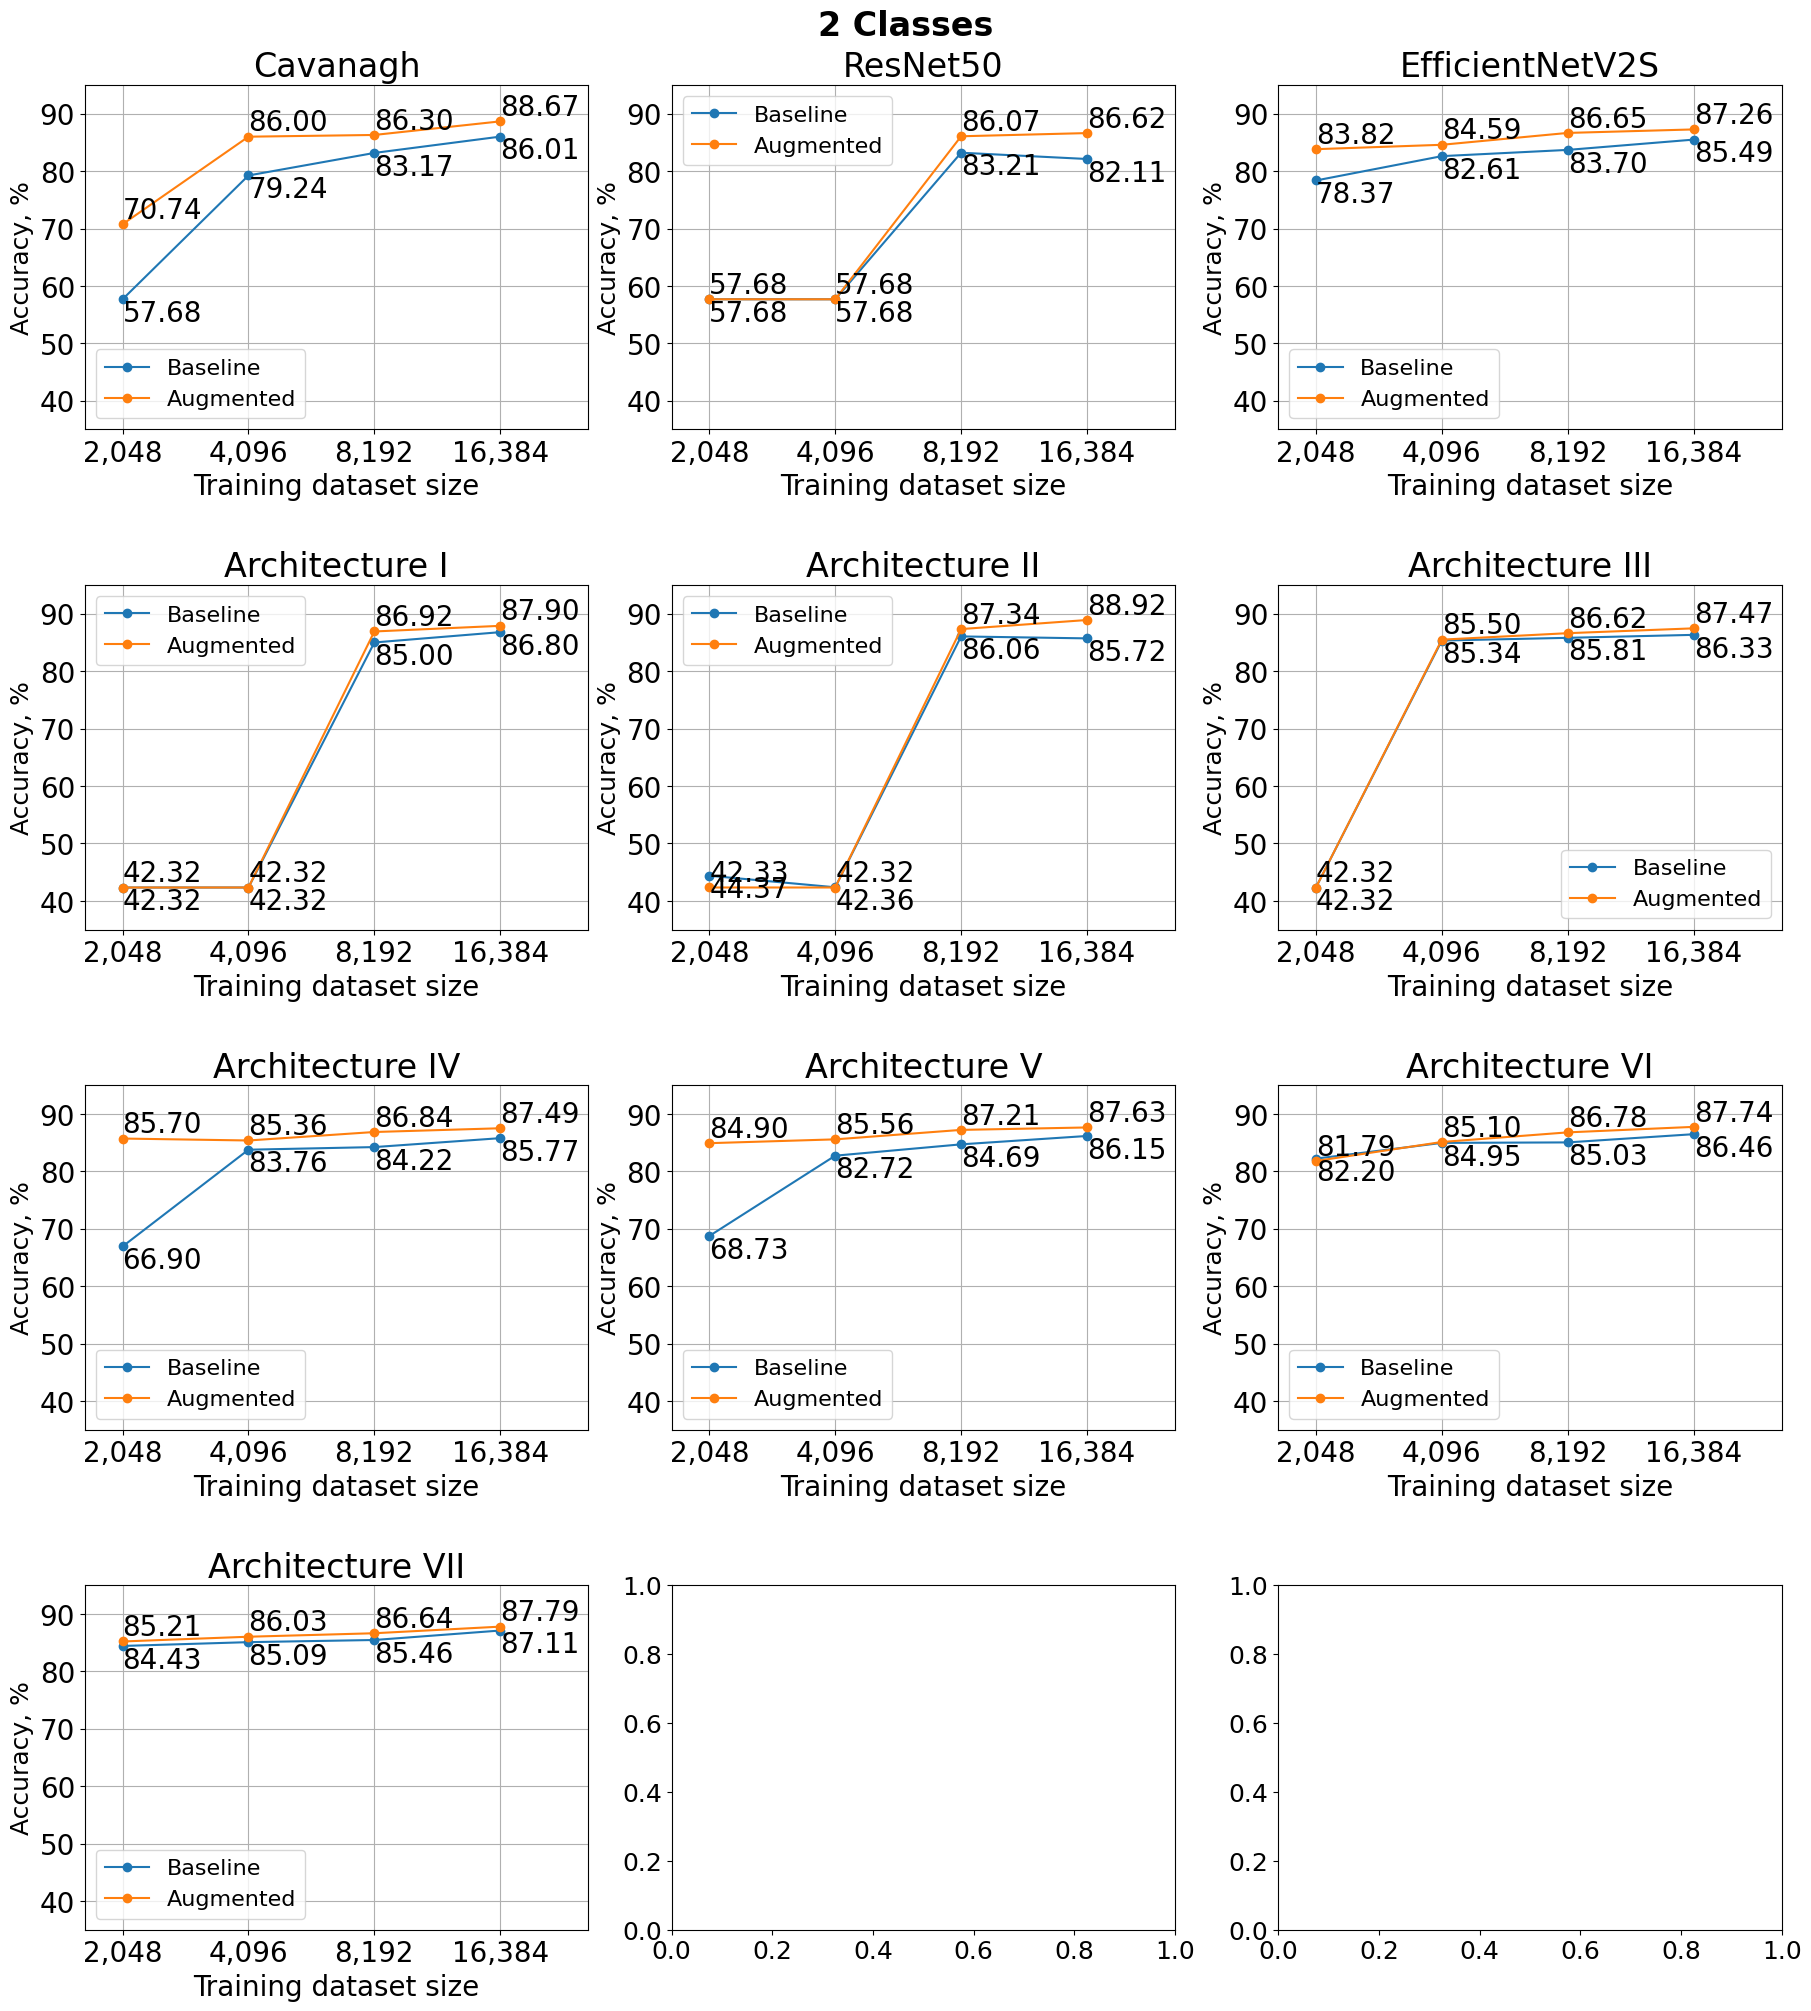

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams.update({'font.size': 18})


models = [
    {"name":"cavanagh", "display_name": "Cavanagh"},
    {"name":"resnet50", "display_name": "ResNet50"},
    {"name":"effnet", "display_name": "EfficientNetV2S"},
    {"name":"custom_by_acc", "display_name": "Architecture I"},
    {"name":"custom_by_loss", "display_name": "Architecture II"},
    {"name":"custom_mbconv", "display_name": "Architecture III"},
    {"name":"custom_mbconv_all", "display_name": "Architecture IV"},
    {"name":"custom_mbconv_improved", "display_name": "Architecture V"},
    {"name":"custom_mbconv_improved_regularized", "display_name": "Architecture VI"},
    {"name":"custom_mbconv_improved_regularized_se", "display_name": "Architecture VII"}
    ]

classes = [2]

classes_dimensions = {
    2: {"min": 35, "max": 95},
    3: {"min": 25, "max": 85},
    5: {"min": 10, "max": 70},
}

splits = [
    { "name": 2048, "display_name": "2,048"},
    { "name": 4096, "display_name": "4,096"},
    { "name": 8192, "display_name": "8,192"},
    { "name": 16384, "display_name": "16,384"},
]

def iqr_plot(ax, means, q1, q3, label, model_name):
    ax.plot([split["display_name"] for split in splits], means, marker="o", label = label)
    for a,b in zip(range(len(means)), means): 
        ax.text(a, b, f"{b:.2f}", fontsize=20, va="bottom" if label != "Baseline" else "top")
    
    if len(means) > len(splits):
        ax.fill_between(range(len(splits)), q1, q3, alpha=0.2, label = "IQR")
    ax.set_title(model_name, fontsize=24)
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)

def get_means_and_iqr(data, model_name):
    means = []
    q1 = []
    q3 = []
    
    for split in splits:
        data_for_split = data[(data["model_name"] == model_name) & (data["split_name"] == split["name"])]["accuracy"] * 100
        means.append(np.median(data_for_split))
        q1.append(np.percentile(data_for_split, 25))
        q3.append(np.percentile(data_for_split, 75))

    means = np.array(means)
    q1 = np.array(q1)
    q3 = np.array(q3)

    return means, q1, q3



fig = plt.figure(constrained_layout=True, figsize=(18, math.ceil(len(models) / 3 * 6)))
fig.set_constrained_layout_pads( wspace=0, hspace=0.1)
subfigs = fig.subfigures(nrows=1, ncols=1)

for class_index, number_of_classes in enumerate(classes):

    subfigs.suptitle(f'{number_of_classes} Classes',fontweight='bold', fontsize=24, y = 1.07 if class_index > 0 else None )

    # create 1x3 subplots per subfig
    ax = subfigs.subplots(nrows=math.ceil(len(models) / 3), ncols=3)

    for model_index, model in enumerate(models):
        model_name = model["name"]
        non_augmented_data = pd.read_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/{number_of_classes}_classes_results_no_augmentations_validation_no_noise.csv")
        augmented_data = pd.read_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/{number_of_classes}_classes_results_with_augmentations_validation_no_noise.csv")
        
        non_augmented_means, non_augmented_q1, non_augmented_q3 = get_means_and_iqr(non_augmented_data, model_name)
        augmented_means, augmented_q1, augmented_q3 = get_means_and_iqr(augmented_data, model_name)

        iqr_plot(ax[model_index // 3][model_index % 3], non_augmented_means, non_augmented_q1, non_augmented_q3, "Baseline", model["display_name"])
        iqr_plot(ax[model_index // 3][model_index % 3], augmented_means, augmented_q1, augmented_q3, "Augmented", model["display_name"])

        # ax[model_index].legend()

        ax[model_index // 3][model_index % 3].set_xlabel("Training dataset size", fontsize=20)
        ax[model_index // 3][model_index % 3].set_ylabel("Accuracy, %")
        ax[model_index // 3][model_index % 3].grid()
        ax[model_index // 3][model_index % 3].set_xlim([-0.3, 3.7])

        dimensions = classes_dimensions[number_of_classes]
        ax[model_index // 3][model_index % 3].set_ylim([dimensions["min"], dimensions["max"]])
        
        ax[model_index // 3][model_index % 3].legend(fontsize=16)

# plt.legend(loc='lower right')

plt.savefig("iqr_line.pdf")

In [ ]:
non_augmented_data = pd.read_csv(f"../Step 2 (Bins) - Image dataset/TFDataset/TrainTestValidation/results/2_classes_results_no_augmentations_validation_no_noise.csv")
non_augmented_data.sort_values(by=["split_name", "f1"], ascending=False)

# IQR Table

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def format(x):
    # return f"${np.median(x * 100):.2f}_{{- {(np.median(x * 100) - np.quantile(x * 100, 0.25)):.2f} }}^{{+ {(np.quantile(x * 100, 0.75) - np.median(x * 100)):.2f} }}$" 
    return f"\\sigmaCell[i]{{{np.median(x * 100):.2f}}}{{{stats.median_abs_deviation(x * 100):.2f}}}" 

non_augmented_data = pd.read_csv(f"5_classes_results_no_augmentations.csv")
augmented_data = pd.read_csv(f"5_classes_results_with_augmentations.csv")

merged_data = pd.merge(non_augmented_data, augmented_data, on=["model_name", "split_name", "fold"], suffixes=("_base", "_augmented"))
merged_data

table = merged_data.groupby(["model_name", "split_name"]).apply(func=
    lambda x:
    pd.Series({
    ("Acc. (MAD)", "Base"): format(x["accuracy_base"]),
    ("Acc. (MAD)", "Augm."): format(x["accuracy_augmented"]),
    ("Prec. (MAD)", "Base"): format(x["precision_base"]),
    ("Prec. (MAD)", "Augm."): format(x["precision_augmented"]),
    ("Recall (MAD)", "Base"): format(x["recall_base"]),
    ("Recall (MAD)", "Augm."): format(x["recall_augmented"]),
    ("F1 (MAD)", "Base"): format(x["f1_base"]),
    ("F1 (MAD)", "Augm."): format(x["f1_augmented"])
    })
    # Precision=('precision', lambda x: format(x)),
    # Recall=('recall', lambda x: format(x)),
    # F1=('f1', lambda x: format(x)),
)

text = table.to_latex(escape=False)

print(text)